### **Feature Engineering ✓**

In [9]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.data_utils import guardar_dataset, plot_distribuciones, plot_distribuciones_por_clase, plot_correlacion, plot_boxplots

El **objetivo** de esta fase será determinar si la creación de alguna feature puede contribuir al modelo y modificar el dataset de X_train en base a ello.

Se prueba a añadir un factor que puede contribuir a la predicción de incendios: el Déficit de Presión de Vapor (VPD). Se calcula como la diferencia entre la cantidad de vapor de agua que hay en el aire y la cantidad máxima que el aire puede retener a una temperatura dada. Es una variable relevante en este contexto porque valores altos de VPD están asociados a mayor sequedad ambiental y, por tanto, a mayor riesgo de ignición y propagación del fuego. Su fórmula es:

$$VPD = e_s - e_a$$

Donde:
- $e_s$ = presión de vapor de saturación (a la temperatura del aire)
- $e_a$ = presión de vapor real (que se obtiene a partir del punto de rocío)

Ambas se calculan con la **ecuación de Magnus-Tetens**:

$$e_s = 0.6108 \cdot \exp\left(\frac{17.27 \cdot T}{T + 237.3}\right)$$

$$e_a = 0.6108 \cdot \exp\left(\frac{17.27 \cdot T_d}{T_d + 237.3}\right)$$

Donde:
- $T$ = temperatura del aire (°C)
- $T_d$ = temperatura del punto de rocío (°C)
- El resultado de $e_s$ y $e_a$ está en **kPa**

Como no se dispone directamente de la presión de vapor real ($e_a$), esta se calcula a partir del **punto de rocío** (o dewpoint, una de las features incluidas en nuestro dataset de estudio), aplicando la misma fórmula de Magnus-Tetens pero sustituyendo $T$ por $T_d$ — esto es válido porque, por definición, el punto de rocío es la temperatura a la que el aire alcanzaría la saturación con la humedad que ya contiene. Creamos entonces una función basada en esta fórmula para crear la variable:

In [10]:
def vpd(temp, dewpoint):
    es = 0.6108 * np.exp(17.27*temp/(temp+237.3))       # presión de vapor de saturación
    ea = 0.6108 * np.exp(17.27*dewpoint/(dewpoint+237.3)) # presión de vapor actual
    return es - ea


In [11]:
X_train = pd.read_csv("../data_sample/train_filtered.csv")
y_train = pd.read_csv("../data_sample/y_train.csv").squeeze()

In [12]:
# Copiamos el dataframe para no modificar direcctamente el original.
X_train_new_feature = X_train.copy()

# Aplicamos la función vpd.
X_train_new_feature["vpd"] = vpd(X_train_new_feature["temp_mean"], X_train_new_feature["dewpoint_mean"])

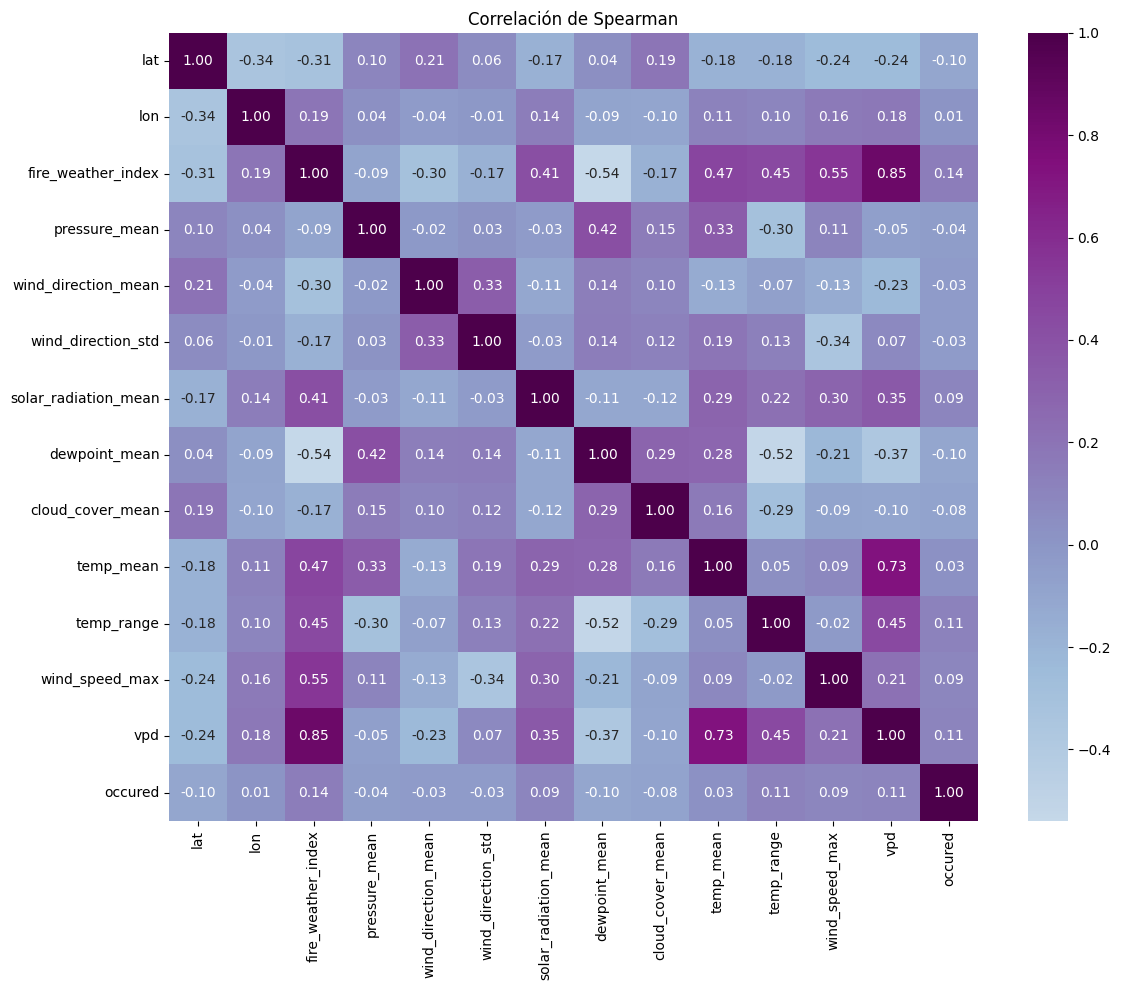

In [13]:
# Observamos como cambian las correlaciones de las features y el target
plot_correlacion(X_train_new_feature, y_train, target_name="occured", excluir="daynight_N")

**Conlcusiones**

La nueva variable vpd se correlaciona mucho con la feature `fire_weather_index` y `temp_mean`, lo que resulta contraproducente para modelos basados en distancias lineales y reduce la parsimonia general del modelo (contienen información redundante). Esto supone que la interpretabilidad del modelo se vea afectada, por lo que se decide eliminarla.

El hecho de que haya una correlación tan fuerte con otro índice ocurre porque ambos están basados en variables fisicoquímicas/meteorológicas compartidas que ya se recogen en la tabla. Lo que es más, el Fire Weather Index ya recoge de partida variables como temperatura, humedad, velocidad del viento y precipitación, muchas de ellas compartidas con el dataset y con otros índices existentes para evaluar los incendios.

Por esta razón se decide **no** crear nuevas variables numércias, pues seguirían llevando a la redundancia de información con `fire_weather_index`, potencialmente introduciendo ruido al modelo.